# 🔍 Hybrid Alpha Optimization for FinanceRAG

## 📋 Overview

Notebook này đánh giá **hybrid_alpha** tốt nhất cho từng dataset để tối ưu kết hợp giữa **Dense Retrieval** và **BM25**.

### 🎯 Objectives:
1. Test alpha values từ 0.1 đến 0.9 (step 0.1)
2. Tìm alpha tối ưu cho từng dataset
3. Phân tích đặc điểm của từng dataset
4. Recommend optimal alpha per dataset

### 🔧 Setup:
- **Embedding Model**: E5-small (best from notebook 0)
- **Reranker**: BGE-reranker-v2-m3 (fixed)
- **Chunking**: Pre-chunked optimal corpus (from notebook 4)
- **Sampling**: 30 queries per dataset (like notebook 0)
- **Alpha**: 0.1, 0.2, ..., 0.9
  - Alpha = 1.0 → 100% Dense retrieval
  - Alpha = 0.0 → 100% BM25
  - Alpha = 0.5 → 50-50 hybrid

---

## 📦 Setup and Imports

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from typing import List, Dict, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
import time
import gc
import torch

warnings.filterwarnings('ignore')

# Embedding & Retrieval libraries
from sentence_transformers import SentenceTransformer
from FlagEmbedding import FlagReranker
from rank_bm25 import BM25Okapi
import faiss

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")
print(f"🖥️ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("   Running on CPU")
    device = 'cpu'

✅ Libraries imported successfully!
🖥️ CUDA available: True
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## ⚙️ Configuration

In [2]:
# Load configuration
from config import (
    DATA_DIR, OUTPUT_DIR, CHUNKED_CORPUS_DIR, CHUNKING_CONFIG_FILE,
    DATASETS, ALPHA_VALUES, EMBEDDING_MODEL,
    SAMPLE_QUERIES_PER_DATASET, MAX_CORPUS_SAMPLE_SIZE,
    TOP_K_RETRIEVAL, TOP_K_RERANK, TOP_K_FINAL,
    EMBED_BATCH_SIZE, RERANK_BATCH_SIZE,
    print_config, print_alpha_config
)

# Create output directory
OUTPUT_DIR.mkdir(exist_ok=True)

# Print configuration
print_config()
print_alpha_config()


📊 Configuration:
   Datasets: 7
   Alpha values to test: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
   Reranker models: 5

📂 Data Source:
   Using pre-chunked corpus: True
   Chunked corpus dir: ..\..\data\chunked_corpus
   Chunking config: ..\..\data\chunked_corpus\best_chunking_config_per_dataset.json

🎯 Retrieval Settings:
   Embedding model: intfloat/e5-small-v2
   Top-k retrieval: 100
   Top-k rerank: 50
   Top-k final: 10

⚡ Speed optimizations:
   Queries per dataset: 30
   Max corpus sample: 500
   Smart sampling: True

🔍 ALPHA EVALUATION CONFIG:
   Alpha range: 0.1 to 0.9
   Step size: 0.1
   Total tests per dataset: 9
   Total tests: 63


## 💾 Memory Check and Optimization


In [ ]:
# Check memory and adjust if needed
if torch.cuda.is_available():
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"💾 GPU Memory: {total_mem:.2f} GB")
    
    if total_mem < 8.0:
        print("   ⚠️ Low memory detected, reducing sample size...")
        SAMPLE_QUERIES_PER_DATASET = 20
        TOP_K_RETRIEVAL = 50
        print(f"   Adjusted: queries={SAMPLE_QUERIES_PER_DATASET}, top_k={TOP_K_RETRIEVAL}")
    else:
        print("   ✅ Sufficient memory")
else:
    print("💻 Running on CPU (slower but stable)")

# Clear cache
if device == 'cuda':
    torch.cuda.empty_cache()
gc.collect()
print("✅ Memory cleared and ready")


## 📚 Import Shared Utilities

In [3]:
# Import data loading functions
from utils import (
    load_jsonl,
    load_prechunked_corpus,
    sample_queries,
    smart_sample_corpus,
    compute_ndcg,
    normalize_scores,
    hybrid_search,
    aggregate_chunk_scores,
    QRELS_MAPPING
)

print("✅ Utility functions imported from utils.py")

✅ Utility functions imported from utils.py


## 🤖 Load Models

In [4]:
print("Loading models...")

# Embedding model (fixed)
print(f"\n1. Loading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL, device=device)
print("   ✅ Done")

# Reranker model (fixed)
reranker_model_name = 'BAAI/bge-reranker-v2-m3'
print(f"\n2. Loading reranker: {reranker_model_name}")
reranker = FlagReranker(reranker_model_name, use_fp16=(device=='cuda'))
print("   ✅ Done")

print("\n✅ All models loaded!")

Loading models...

1. Loading embedding model: intfloat/e5-small-v2
   ✅ Done

2. Loading reranker: BAAI/bge-reranker-v2-m3
   ✅ Done

✅ All models loaded!


## 🎯 Alpha Evaluation Function

In [5]:
def evaluate_alpha_on_dataset(
    dataset_name: str,
    alpha: float,
    embed_model,
    reranker,
    device: str
) -> Dict:
    """
    Evaluate a specific alpha value on a dataset.
    
    Args:
        dataset_name: Name of the dataset
        alpha: Hybrid alpha value (0.0 to 1.0)
        embed_model: Embedding model
        reranker: Reranker model
        device: 'cuda' or 'cpu'
        
    Returns:
        Dict with NDCG@10 and other metrics
    """
    # Load pre-chunked corpus
    chunks, chunking_method = load_prechunked_corpus(
        dataset_name,
        CHUNKED_CORPUS_DIR,
        CHUNKING_CONFIG_FILE
    )
    
    if not chunks:
        return {'ndcg_10': 0.0, 'error': 'Failed to load chunks'}
    
    # Build chunk-to-doc mapping
    chunk_to_doc = {}
    for c in chunks:
        chunk_id = c.get('_id', c.get('chunk_id', ''))
        doc_id = c.get('original_id', c.get('doc_id', chunk_id))
        chunk_to_doc[chunk_id] = doc_id
    
    chunk_texts = [c.get('text', '') for c in chunks]
    chunk_ids = [c.get('_id', c.get('chunk_id', '')) for c in chunks]
    
    # Load queries and qrels
    queries_path = DATA_DIR / f"{dataset_name}_queries.jsonl" / "queries.jsonl"
    queries = load_jsonl(queries_path)
    
    qrels_path = DATA_DIR / QRELS_MAPPING[dataset_name]
    qrels_dict = {}
    if qrels_path.exists():
        qrels_df = pd.read_csv(qrels_path, sep='\t')
        query_col = 'query_id' if 'query_id' in qrels_df.columns else 'query-id'
        corpus_col = 'corpus_id' if 'corpus_id' in qrels_df.columns else 'corpus-id'
        score_col = 'score' if 'score' in qrels_df.columns else 'relevance'
        
        for _, row in qrels_df.iterrows():
            qid = str(row[query_col])
            cid = str(row[corpus_col])
            score = int(row[score_col])
            if qid not in qrels_dict:
                qrels_dict[qid] = {}
            qrels_dict[qid][cid] = score
    
    # Sample queries
    queries_sample = sample_queries(queries, qrels_dict, SAMPLE_QUERIES_PER_DATASET)
    
    # Encode chunks
    chunk_embeddings = embed_model.encode(
        chunk_texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    # Build FAISS index
    index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
    index.add(chunk_embeddings.astype('float32'))
    
    # Build BM25 index
    tokenized = [t.lower().split() for t in chunk_texts]
    bm25 = BM25Okapi(tokenized)
    
    # Process queries
    query_texts = [q.get('text', '') for q in queries_sample]
    query_ids = [q.get('_id', '') for q in queries_sample]
    
    query_embeddings = embed_model.encode(
        query_texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    # Retrieve and rerank with specific alpha
    results_dict = {}
    
    for i, query_id in enumerate(query_ids):
        query_emb = query_embeddings[i]
        query_text = query_texts[i]
        
        # Hybrid search with alpha
        scores, chunk_indices = hybrid_search(
            query_emb, query_text, index, bm25, chunk_texts,
            TOP_K_RETRIEVAL, alpha
        )
        
        # Aggregate chunks to documents
        doc_scores = {}
        for idx, score in zip(chunk_indices, scores):
            doc_id = chunk_to_doc[chunk_ids[idx]]
            if doc_id not in doc_scores:
                doc_scores[doc_id] = []
            doc_scores[doc_id].append(float(score))
        
        doc_agg = aggregate_chunk_scores(doc_scores, 'max')
        sorted_docs = sorted(doc_agg.items(), key=lambda x: x[1], reverse=True)[:TOP_K_RERANK]
        
        # Rerank top documents
        candidate_ids = [d[0] for d in sorted_docs]
        
        # Get original corpus texts for reranking (from chunks)
        candidate_texts = []
        for doc_id in candidate_ids:
            # Find chunks belonging to this doc
            doc_chunks = [chunk_texts[j] for j, cid in enumerate(chunk_ids) if chunk_to_doc[cid] == doc_id]
            # Use first chunk or concatenate (limit to 2048 chars)
            candidate_texts.append(' '.join(doc_chunks)[:2048])
        
        pairs = [[query_text, t] for t in candidate_texts]
        rerank_scores = reranker.compute_score(pairs)
        
        if not isinstance(rerank_scores, list):
            rerank_scores = [rerank_scores]
        
        scored = list(zip(candidate_ids, rerank_scores))
        scored.sort(key=lambda x: x[1], reverse=True)
        
        # Store top-k final
        results_dict[query_id] = [doc_id for doc_id, _ in scored[:TOP_K_FINAL]]
    
    # Compute NDCG@10
    ndcg_scores = []
    for qid, retrieved in results_dict.items():
        if qid in qrels_dict:
            ndcg = compute_ndcg(retrieved, qrels_dict[qid], k=10)
            ndcg_scores.append(ndcg)
    
    avg_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0.0
    
    # Clean up
    del chunk_embeddings, query_embeddings, index, bm25
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    
    return {
        'dataset': dataset_name,
        'alpha': alpha,
        'ndcg_10': float(avg_ndcg),
        'num_queries': len(ndcg_scores),
        'chunking_method': chunking_method
    }


print("✅ Alpha evaluation function defined")

✅ Alpha evaluation function defined


## 🚀 Run Alpha Evaluation

Test all alpha values across all datasets:

In [6]:
results = []

print("\n" + "="*80)
print("🚀 STARTING HYBRID ALPHA EVALUATION")
print("="*80)

total_tests = len(DATASETS) * len(ALPHA_VALUES)
pbar = tqdm(total=total_tests, desc="Overall progress")

for dataset in DATASETS:
    print(f"\n{'='*80}")
    print(f"📊 Dataset: {dataset.upper()}")
    print(f"{'='*80}")
    
    for alpha in ALPHA_VALUES:
        try:
            print(f"\n  Testing alpha={alpha:.1f}...", end=' ')
            
            result = evaluate_alpha_on_dataset(
                dataset,
                alpha,
                embed_model,
                reranker,
                device
            )
            
            results.append(result)
            print(f"NDCG@10: {result['ndcg_10']:.4f}")
            
        except Exception as e:
            print(f"❌ Error: {e}")
            results.append({
                'dataset': dataset,
                'alpha': alpha,
                'ndcg_10': 0.0,
                'error': str(e)
            })
        
        pbar.update(1)

pbar.close()

print("\n" + "="*80)
print("✅ ALPHA EVALUATION COMPLETED!")
print("="*80)


🚀 STARTING HYBRID ALPHA EVALUATION


Overall progress:   0%|          | 0/63 [00:00<?, ?it/s]


📊 Dataset: CONVFINQA

  Testing alpha=0.1...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


NDCG@10: 0.4385

  Testing alpha=0.2...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

  Testing alpha=0.3...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

  Testing alpha=0.4...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

  Testing alpha=0.5...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

  Testing alpha=0.6...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4218

  Testing alpha=0.7...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

  Testing alpha=0.8...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4052

  Testing alpha=0.9...   ✅ Loaded 38909 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.4385

📊 Dataset: FINANCEBENCH

  Testing alpha=0.1...   ✅ Loaded 421 pre-chunked chunks
  📋 Method used: unknown
NDCG@10: 0.7702

  Testing alpha=0.2...   ✅ Loaded 421 pre-chunked c

## 📊 Results Analysis

In [7]:
# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save raw results
results_df.to_csv(OUTPUT_DIR / 'alpha_evaluation_results.csv', index=False)
print(f"✅ Results saved to: {OUTPUT_DIR / 'alpha_evaluation_results.csv'}")

# Display results
print("\n📋 All Results:")
print(results_df.to_string(index=False))

✅ Results saved to: output_hybrid_rerank_eval\alpha_evaluation_results.csv

📋 All Results:
     dataset  alpha  ndcg_10  num_queries chunking_method
   convfinqa    0.1 0.438488           30         unknown
   convfinqa    0.2 0.438488           30         unknown
   convfinqa    0.3 0.438488           30         unknown
   convfinqa    0.4 0.438488           30         unknown
   convfinqa    0.5 0.438488           30         unknown
   convfinqa    0.6 0.421822           30         unknown
   convfinqa    0.7 0.438488           30         unknown
   convfinqa    0.8 0.405155           30         unknown
   convfinqa    0.9 0.438488           30         unknown
financebench    0.1 0.770179           30         unknown
financebench    0.2 0.794527           30         unknown
financebench    0.3 0.822560           30         unknown
financebench    0.4 0.833671           30         unknown
financebench    0.5 0.867005           30         unknown
financebench    0.6 0.867005           

## 🎯 Find Best Alpha per Dataset

In [8]:
# Find best alpha for each dataset
best_alphas = []

print("\n" + "="*80)
print("🏆 BEST ALPHA PER DATASET")
print("="*80)
print(f"\n{'Dataset':<15} {'Best Alpha':<12} {'NDCG@10':<12} {'Interpretation':<30}")
print("-"*80)

for dataset in DATASETS:
    dataset_results = results_df[results_df['dataset'] == dataset]
    
    if len(dataset_results) > 0:
        best_row = dataset_results.loc[dataset_results['ndcg_10'].idxmax()]
        best_alpha = best_row['alpha']
        best_ndcg = best_row['ndcg_10']
        
        # Interpretation
        if best_alpha >= 0.7:
            interp = "Dense-heavy 🎯"
        elif best_alpha >= 0.5:
            interp = "Balanced ⚖️"
        else:
            interp = "BM25-heavy 🔤"
        
        print(f"{dataset:<15} {best_alpha:<12.1f} {best_ndcg:<12.4f} {interp:<30}")
        
        best_alphas.append({
            'dataset': dataset,
            'best_alpha': best_alpha,
            'ndcg_10': best_ndcg,
            'interpretation': interp
        })

print("-"*80)

# Save best alphas
best_alphas_df = pd.DataFrame(best_alphas)
best_alphas_df.to_csv(OUTPUT_DIR / 'best_alpha_per_dataset.csv', index=False)
print(f"\n✅ Best alphas saved to: {OUTPUT_DIR / 'best_alpha_per_dataset.csv'}")


🏆 BEST ALPHA PER DATASET

Dataset         Best Alpha   NDCG@10      Interpretation                
--------------------------------------------------------------------------------
convfinqa       0.1          0.4385       BM25-heavy 🔤                  
financebench    0.5          0.8670       Balanced ⚖️                   
finder          0.4          0.4575       BM25-heavy 🔤                  
finqa           0.9          0.4176       Dense-heavy 🎯                 
finqabench      0.1          0.8716       BM25-heavy 🔤                  
multiheirtt     0.1          0.0928       BM25-heavy 🔤                  
tatqa           0.5          0.4224       Balanced ⚖️                   
--------------------------------------------------------------------------------

✅ Best alphas saved to: output_hybrid_rerank_eval\best_alpha_per_dataset.csv


## 📈 Visualization: Alpha vs NDCG

✅ Plot saved to: output_hybrid_rerank_eval\alpha_vs_ndcg_per_dataset.png


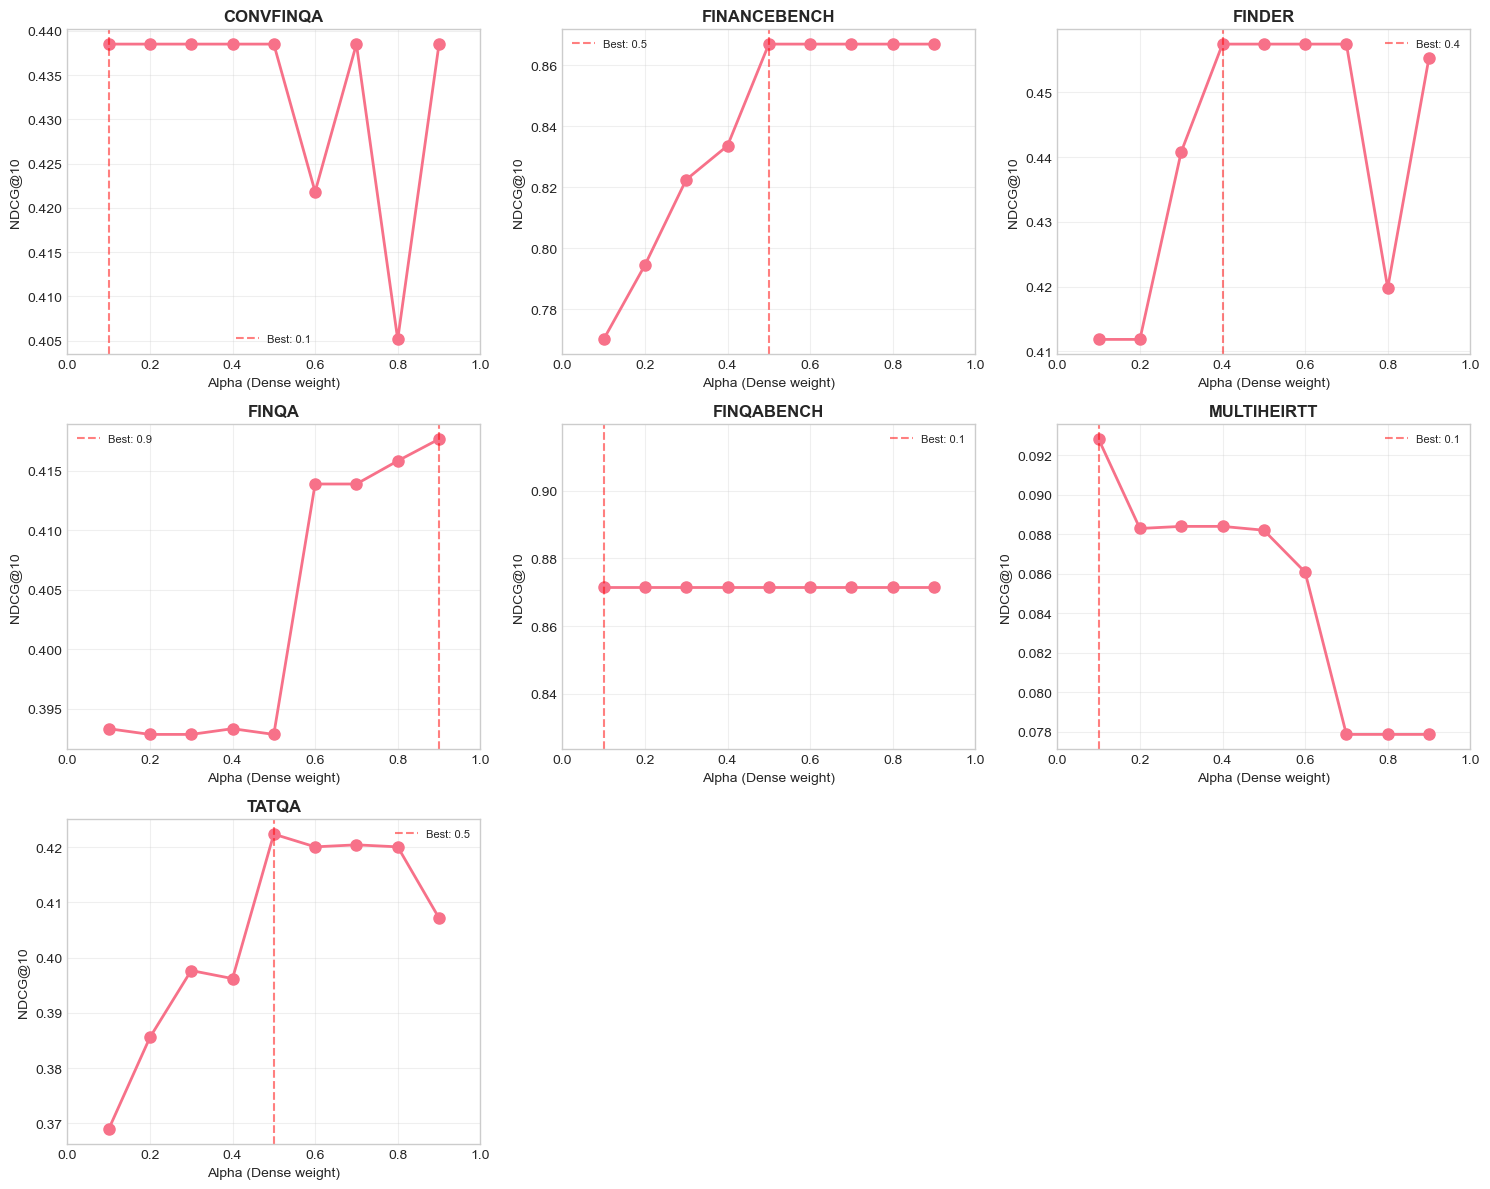

In [9]:
# Plot alpha vs NDCG for each dataset
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, dataset in enumerate(DATASETS):
    ax = axes[i]
    dataset_results = results_df[results_df['dataset'] == dataset]
    
    ax.plot(dataset_results['alpha'], dataset_results['ndcg_10'], 
            marker='o', linewidth=2, markersize=8)
    ax.set_xlabel('Alpha (Dense weight)', fontsize=10)
    ax.set_ylabel('NDCG@10', fontsize=10)
    ax.set_title(f'{dataset.upper()}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    
    # Mark best alpha
    best_row = dataset_results.loc[dataset_results['ndcg_10'].idxmax()]
    ax.axvline(best_row['alpha'], color='red', linestyle='--', alpha=0.5, label=f"Best: {best_row['alpha']:.1f}")
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-2].axis('off')
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'alpha_vs_ndcg_per_dataset.png', dpi=300, bbox_inches='tight')
print(f"✅ Plot saved to: {OUTPUT_DIR / 'alpha_vs_ndcg_per_dataset.png'}")
plt.show()

## 📊 Heatmap: Dataset vs Alpha

✅ Heatmap saved to: output_hybrid_rerank_eval\alpha_heatmap.png


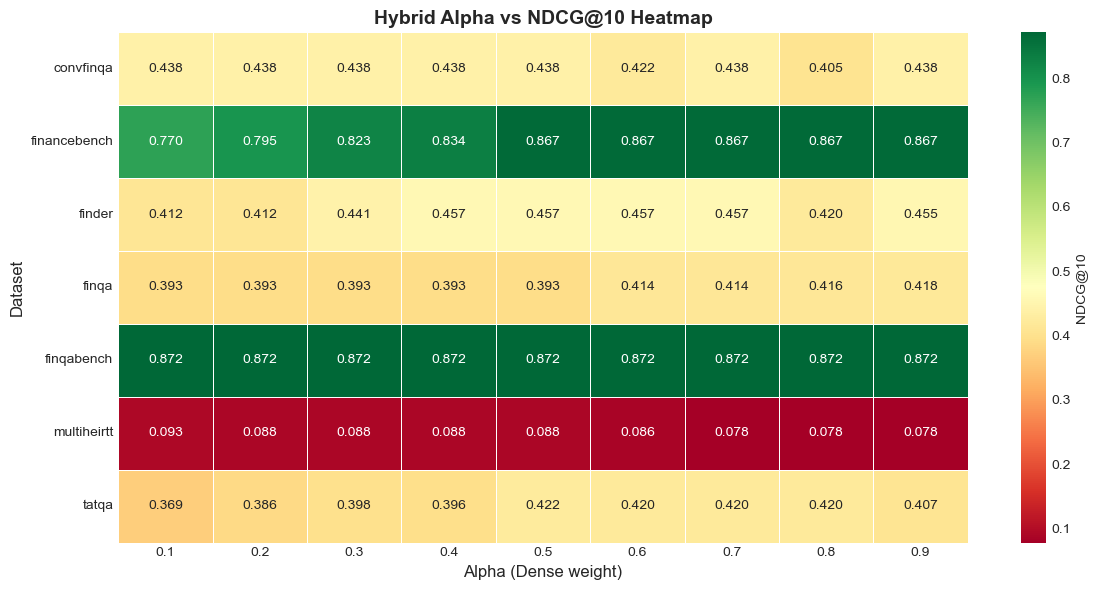

In [10]:
# Create pivot table for heatmap
pivot_df = results_df.pivot(index='dataset', columns='alpha', values='ndcg_10')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='RdYlGn', 
            linewidths=0.5, cbar_kws={'label': 'NDCG@10'})
plt.title('Hybrid Alpha vs NDCG@10 Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Alpha (Dense weight)', fontsize=12)
plt.ylabel('Dataset', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'alpha_heatmap.png', dpi=300, bbox_inches='tight')
print(f"✅ Heatmap saved to: {OUTPUT_DIR / 'alpha_heatmap.png'}")
plt.show()

## 📝 Summary Report

In [11]:
# Generate summary report
print("\n" + "="*80)
print("📝 ALPHA EVALUATION SUMMARY REPORT")
print("="*80)

print("\n🔍 Key Findings:")
print("-"*80)

# Count preference types
dense_heavy = sum(1 for a in best_alphas if a['best_alpha'] >= 0.7)
balanced = sum(1 for a in best_alphas if 0.5 <= a['best_alpha'] < 0.7)
bm25_heavy = sum(1 for a in best_alphas if a['best_alpha'] < 0.5)

print(f"\n1. Dataset Preferences:")
print(f"   - Dense-heavy (α ≥ 0.7): {dense_heavy} datasets")
print(f"   - Balanced (0.5 ≤ α < 0.7): {balanced} datasets")
print(f"   - BM25-heavy (α < 0.5): {bm25_heavy} datasets")

# Average best alpha
avg_best_alpha = np.mean([a['best_alpha'] for a in best_alphas])
print(f"\n2. Average Best Alpha: {avg_best_alpha:.2f}")

# Performance improvement
print(f"\n3. Best NDCG@10 per Dataset:")
for item in best_alphas:
    print(f"   - {item['dataset']:<15}: {item['ndcg_10']:.4f} (α={item['best_alpha']:.1f})")

# Overall average
avg_ndcg = np.mean([a['ndcg_10'] for a in best_alphas])
print(f"\n4. Average NDCG@10 (with optimal alpha): {avg_ndcg:.4f}")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE!")
print("="*80)

# Save report
report_path = OUTPUT_DIR / 'alpha_evaluation_report.txt'
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("HYBRID ALPHA EVALUATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dataset Preferences:\n")
    f.write(f"  Dense-heavy: {dense_heavy}\n")
    f.write(f"  Balanced: {balanced}\n")
    f.write(f"  BM25-heavy: {bm25_heavy}\n\n")
    f.write(f"Average Best Alpha: {avg_best_alpha:.2f}\n\n")
    f.write(f"Best Alpha per Dataset:\n")
    for item in best_alphas:
        f.write(f"  {item['dataset']}: α={item['best_alpha']:.1f}, NDCG@10={item['ndcg_10']:.4f}\n")
    f.write(f"\nAverage NDCG@10: {avg_ndcg:.4f}\n")

print(f"\n📄 Report saved to: {report_path}")


📝 ALPHA EVALUATION SUMMARY REPORT

🔍 Key Findings:
--------------------------------------------------------------------------------

1. Dataset Preferences:
   - Dense-heavy (α ≥ 0.7): 1 datasets
   - Balanced (0.5 ≤ α < 0.7): 2 datasets
   - BM25-heavy (α < 0.5): 4 datasets

2. Average Best Alpha: 0.37

3. Best NDCG@10 per Dataset:
   - convfinqa      : 0.4385 (α=0.1)
   - financebench   : 0.8670 (α=0.5)
   - finder         : 0.4575 (α=0.4)
   - finqa          : 0.4176 (α=0.9)
   - finqabench     : 0.8716 (α=0.1)
   - multiheirtt    : 0.0928 (α=0.1)
   - tatqa          : 0.4224 (α=0.5)

4. Average NDCG@10 (with optimal alpha): 0.5096

✅ EVALUATION COMPLETE!

📄 Report saved to: output_hybrid_rerank_eval\alpha_evaluation_report.txt
